# 04 — Unsupervised clustering

## Objective

Use K-means clustering to identify groups of CROME cells with similar 2024 land-use characteristics, confidence scores and geographical locations.

Unlike supervised classification, clustering is not given a correct target. The algorithm discovers patterns within the predictor data itself. The 2025 classifications will be used only afterwards to help interpret the resulting clusters.

In [17]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [18]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

prepared_data_path = (
    project_root
    / "data"
    / "interim"
    / "crome_prepared_data.gpkg"
)

data = gpd.read_file(
    prepared_data_path,
    layer="prepared_data"
)

print("Data shape:", data.shape)
print("CRS:", data.crs)
print(
    "Missing values:",
    data.isna().sum().sum()
)

data.head()

Data shape: (4868, 9)
CRS: EPSG:4326
Missing values: 0


,cromeid,lucode_2024,land_use_2024,confidence_2024,easting,northing,target_2025,target_name_2025,geometry
0,RPA512626340510,PG01,Grass,0.320,512626.778605,340512.123903,AC66,Winter Wheat,"POLYGON ((-0.32484 52.94986, -0.32544 52.94987..."
1,RPA513046344216,AC66,Winter Wheat,0.297,513046.696018,344218.716060,AC66,Winter Wheat,"POLYGON ((-0.31699 52.98339, -0.3173 52.98308,..."
2,RPA512026344112,AC66,Winter Wheat,0.577,512026.721345,344114.825388,AC03,Beet,"POLYGON ((-0.33312 52.98237, -0.33341 52.98268..."
3,RPA512386340579,FA01,Fallow Land,0.182,512386.762061,340581.398936,AC66,Winter Wheat,"POLYGON ((-0.32808 52.95084, -0.32839 52.95054..."
4,RPA513286341168,AC66,Winter Wheat,0.462,513286.771223,341170.282658,LG20,Winter Field beans,"POLYGON ((-0.31479 52.95564, -0.31539 52.95565..."


## 1. Prepare the clustering features

Clustering uses only information available from 2024. The 2025 class is excluded while the clusters are created and retained only for later interpretation.

The land-use code is one-hot encoded. Confidence and location are standardised so that their different numerical scales do not dominate the distance calculation.

In [19]:
clustering_features = [
    "lucode_2024",
    "confidence_2024",
    "easting",
    "northing"
]

clustering_data = data[
    clustering_features
].copy()

categorical_features = [
    "lucode_2024"
]

numerical_features = [
    "confidence_2024",
    "easting",
    "northing"
]

clustering_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

X_cluster = (
    clustering_preprocessor
    .fit_transform(clustering_data)
)

print(
    "Original feature shape:",
    clustering_data.shape
)

print(
    "Transformed feature shape:",
    X_cluster.shape
)

Original feature shape: (4868, 4)
Transformed feature shape: (4868, 22)


## 2. Select the number of clusters

K-means requires the number of clusters to be chosen in advance. Solutions containing between two and eight clusters are compared using inertia and the silhouette score.

In [20]:
cluster_results = []

for number_of_clusters in range(2, 9):
    kmeans_model = KMeans(
        n_clusters=number_of_clusters,
        n_init=20,
        random_state=42
    )

    cluster_labels = (
        kmeans_model.fit_predict(
            X_cluster
        )
    )

    silhouette = silhouette_score(
        X_cluster,
        cluster_labels,
        sample_size=2_000,
        random_state=42
    )

    cluster_results.append({
        "clusters": number_of_clusters,
        "inertia": kmeans_model.inertia_,
        "silhouette_score": silhouette
    })

cluster_evaluation = pd.DataFrame(
    cluster_results
)

cluster_evaluation.round(3)

,clusters,inertia,silhouette_score
0,2,14519.068,0.213
1,3,12126.799,0.203
2,4,10503.628,0.215
3,5,9328.373,0.206
4,6,8441.693,0.212
5,7,7896.349,0.193
6,8,7395.630,0.196


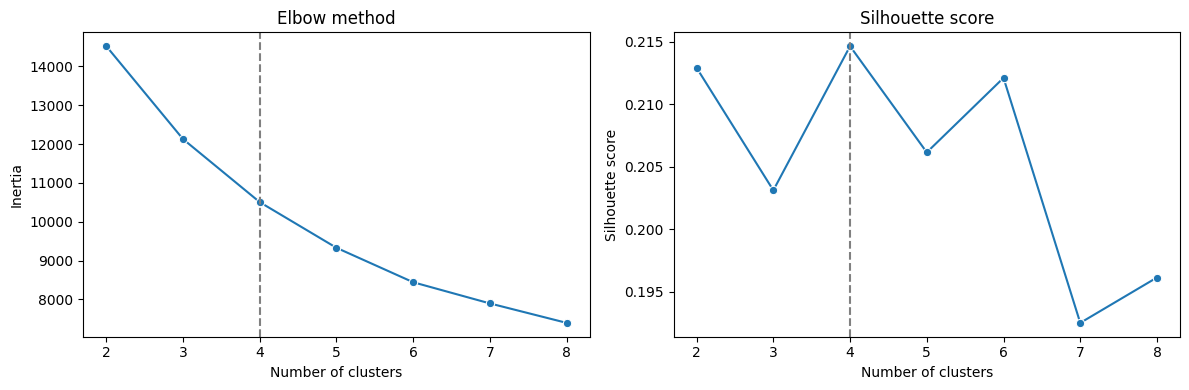

In [22]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

sns.lineplot(
    data=cluster_evaluation,
    x="clusters",
    y="inertia",
    marker="o",
    ax=axes[0]
)

axes[0].axvline(
    4,
    color="grey",
    linestyle="--"
)

axes[0].set_title(
    "Elbow method"
)

axes[0].set_xlabel(
    "Number of clusters"
)

axes[0].set_ylabel(
    "Inertia"
)

sns.lineplot(
    data=cluster_evaluation,
    x="clusters",
    y="silhouette_score",
    marker="o",
    ax=axes[1]
)

axes[1].axvline(
    4,
    color="grey",
    linestyle="--"
)

axes[1].set_title(
    "Silhouette score"
)

axes[1].set_xlabel(
    "Number of clusters"
)

axes[1].set_ylabel(
    "Silhouette score"
)

plt.tight_layout()
plt.show()

### Selected cluster solution

Four clusters were selected because this solution produced the highest
silhouette score of the alternatives tested, at 0.215. The inertia curve
also showed that the improvements became progressively smaller as more
clusters were added.

The silhouette score is relatively low, indicating that the groups overlap.
The clusters should therefore be interpreted as broad geographical and
agricultural patterns rather than completely separate categories.

## 3. Fit and map the final clusters

In [23]:
selected_clusters = 4

final_kmeans_model = KMeans(
    n_clusters=selected_clusters,
    n_init=20,
    random_state=42
)

data["cluster"] = (
    final_kmeans_model.fit_predict(
        X_cluster
    )
    + 1
)

data["cluster_label"] = (
    "Cluster "
    + data["cluster"].astype(str)
)

cluster_sizes = (
    data["cluster_label"]
    .value_counts()
    .sort_index()
)

cluster_sizes

cluster_label
Cluster 1    1175
Cluster 2    1222
Cluster 3    1418
Cluster 4    1053
Name: count, dtype: int64

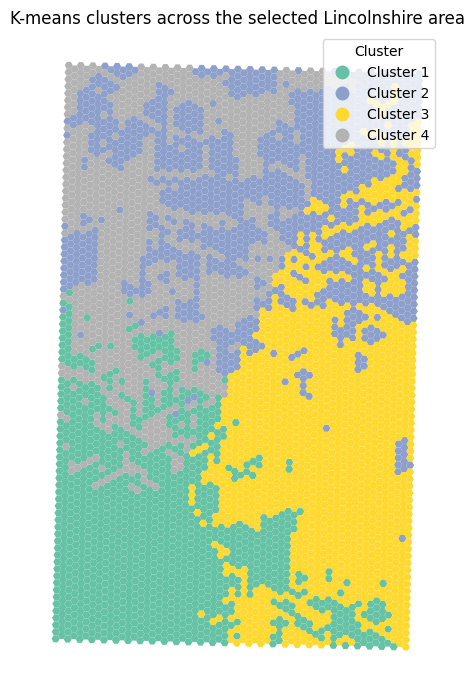

In [24]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)

data.plot(
    column="cluster_label",
    categorical=True,
    legend=True,
    cmap="Set2",
    linewidth=0,
    ax=ax,
    legend_kwds={
        "title": "Cluster"
    }
)

ax.set_title(
    "K-means clusters across the selected Lincolnshire area"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

## 4. Profile the clusters

The cluster labels created by K-means do not have an automatic agricultural
meaning. This section examines the size, location, confidence and 2024
land-use composition of each cluster.

### 4.1 Cluster sizes and characteristics

In [25]:
cluster_profile = (
    data.groupby("cluster_label")
    .agg(
        cells=("cromeid", "size"),
        mean_confidence=(
            "confidence_2024",
            "mean"
        ),
        mean_easting=(
            "easting",
            "mean"
        ),
        mean_northing=(
            "northing",
            "mean"
        )
    )
)

cluster_profile[
    "share_percentage"
] = (
    cluster_profile["cells"]
    / len(data)
    * 100
)

cluster_profile = cluster_profile[
    [
        "cells",
        "share_percentage",
        "mean_confidence",
        "mean_easting",
        "mean_northing"
    ]
]

cluster_profile.round(2)

,cells,share_percentage,mean_confidence,mean_easting,mean_northing
cluster_label,,,,,
Cluster 1,1175,24.14,0.50,511883.07,341600.82
Cluster 2,1222,25.10,0.68,512809.84,344825.09
Cluster 3,1418,29.13,0.27,513472.76,342528.58
Cluster 4,1053,21.63,0.28,511827.39,344388.32


#### Interpretation of the cluster profiles

The four clusters were reasonably balanced in size. Cluster 3 was the
largest, containing 29.13% of the cells, while Cluster 4 was the smallest,
containing 21.63%.

The average easting and northing values indicate the approximate
geographical position of each cluster:

- Cluster 1 was concentrated mainly in the south-western part of the area.
- Cluster 2 was concentrated mainly in the northern and eastern area.
- Cluster 3 was concentrated mainly in the eastern and southern area.
- Cluster 4 was concentrated mainly in the northern and western area.

Cluster 2 had the highest average 2024 classification confidence, at 0.68.
Cluster 1 had moderate average confidence of 0.50. Clusters 3 and 4 had
lower average confidence, at 0.27 and 0.28 respectively.

A higher confidence score means that the CROME classification system was
more certain about its assigned land-use code. It does not represent land
quality or agricultural performance.

### 4.2 Most common 2024 land uses within each cluster

The three most common 2024 land uses are calculated to help give the
numerical cluster labels an agricultural interpretation.

In [27]:
cluster_land_use = (
    data.groupby(
        ["cluster_label", "land_use_2024"]
    )
    .size()
    .reset_index(name="cells")
)

cluster_land_use["cluster_total"] = (
    cluster_land_use
    .groupby("cluster_label")["cells"]
    .transform("sum")
)

cluster_land_use["percentage_within_cluster"] = (
    cluster_land_use["cells"]
    / cluster_land_use["cluster_total"]
    * 100
)

top_land_uses = (
    cluster_land_use
    .sort_values(
        ["cluster_label", "cells"],
        ascending=[True, False]
    )
    .groupby(
        "cluster_label",
        group_keys=False
    )
    .head(3)
    .reset_index(drop=True)
)

top_land_uses[
    [
        "cluster_label",
        "land_use_2024",
        "cells",
        "percentage_within_cluster"
    ]
].round(2)

,cluster_label,land_use_2024,cells,percentage_within_cluster
0,Cluster 1,Maize,202,17.19
1,Cluster 1,Winter Wheat,168,14.30
2,Cluster 1,Fallow Land,153,13.02
3,Cluster 2,Winter Wheat,766,62.68
4,Cluster 2,Winter Oilseed,183,14.98
5,Cluster 2,Grass,100,8.18
6,Cluster 3,Winter Wheat,261,18.41
7,Cluster 3,Grass,119,8.39
8,Cluster 3,Spring Barley,115,8.11
9,Cluster 4,Winter Wheat,227,21.56


### Interpretation of the clusters

The four clusters represent different combinations of geographical
location, 2024 land use and classification confidence.

- **Cluster 1 – South-west mixed arable:** Maize was the most common
  classification, followed by Winter Wheat and Fallow Land. No single
  land use dominated the cluster.

- **Cluster 2 – High-confidence winter cropping:** Winter Wheat accounted
  for 62.68% of the cluster, followed by Winter Oilseed. This cluster also
  had the highest average classification confidence, at 0.68.

- **Cluster 3 – Eastern mixed farming:** Winter Wheat was the largest
  category, but represented only 18.41% of cells. Grass and Spring Barley
  were also common, indicating a relatively diverse cluster.

- **Cluster 4 – North-west mixed land use:** Winter Wheat, Grass and
  Fallow Land were the leading classifications. Like Cluster 3, this
  cluster had relatively low average classification confidence.

The cluster numbers are arbitrary labels rather than rankings. The top
three percentages do not add up to 100% because each cluster also contains
several other land-use classifications.

## 5. Examine the 2025 outcomes

The clusters were created using only 2024 information. The 2025
classifications are examined afterwards to understand what happened
to the cells in each cluster one year later.

### 5.1 2025 land-use outcomes by cluster

In [28]:
cluster_land_use_2025 = (
    data.groupby(
        ["cluster_label", "target_name_2025"]
    )
    .size()
    .reset_index(name="cells")
)

cluster_land_use_2025["cluster_total"] = (
    cluster_land_use_2025
    .groupby("cluster_label")["cells"]
    .transform("sum")
)

cluster_land_use_2025["percentage_within_cluster"] = (
    cluster_land_use_2025["cells"]
    / cluster_land_use_2025["cluster_total"]
    * 100
)

top_land_uses_2025 = (
    cluster_land_use_2025
    .sort_values(
        ["cluster_label", "cells"],
        ascending=[True, False]
    )
    .groupby(
        "cluster_label",
        group_keys=False
    )
    .head(3)
    .reset_index(drop=True)
)

top_land_uses_2025[
    [
        "cluster_label",
        "target_name_2025",
        "cells",
        "percentage_within_cluster"
    ]
].round(2)

,cluster_label,target_name_2025,cells,percentage_within_cluster
0,Cluster 1,Winter Wheat,683,58.13
1,Cluster 1,Cover Crop,84,7.15
2,Cluster 1,Non-vegetated or sparsely-vegetated Land,75,6.38
3,Cluster 2,Winter Wheat,460,37.64
4,Cluster 2,Winter Oilseed,198,16.20
5,Cluster 2,Non-vegetated or sparsely-vegetated Land,106,8.67
6,Cluster 3,Winter Wheat,729,51.41
7,Cluster 3,Cover Crop,208,14.67
8,Cluster 3,Beet,65,4.58
9,Cluster 4,Winter Wheat,382,36.28


### Interpretation of the 2025 outcomes

The clusters were created using only 2024 information. The 2025
classifications were then examined to understand the following year's
land-use distribution within each cluster.

Winter Wheat was the most common 2025 classification in all four clusters,
although its importance differed considerably:

- Cluster 1 had the largest Winter Wheat share, at 58.13%.
- Cluster 2 remained associated with winter crops, but its Winter Wheat
  share fell from 62.68% in 2024 to 37.64% in 2025.
- Cluster 3 experienced a substantial increase in Winter Wheat, from
  18.41% to 51.41%.
- Cluster 4 remained relatively mixed, with Winter Wheat and Cover Crop
  representing 36.28% and 19.09% respectively.

Cover Crop was an important 2025 outcome in Clusters 3 and 4.

These aggregated percentages describe the composition of each cluster.
They do not, by themselves, show the exact transition made by every
individual cell. Differences may reflect crop rotation as well as
uncertainty in the annual CROME classifications.

### 5.2 Classification-change rates

The following analysis compares each cell's 2024 and 2025 classification.
Cells assigned to the grouped `OTHER` target are excluded because their
precise 2025 land-use codes are unavailable in the prepared dataset.

In [29]:
change_data = data.loc[
    data["target_2025"] != "OTHER"
].copy()

change_data["classification_changed"] = (
    change_data["lucode_2024"]
    != change_data["target_2025"]
)

cluster_change_summary = (
    change_data
    .groupby("cluster_label")
    .agg(
        evaluated_cells=("cromeid", "size"),
        changed_cells=("classification_changed", "sum"),
        change_rate=("classification_changed", "mean")
    )
    .reset_index()
)

cluster_change_summary["change_rate"] = (
    cluster_change_summary["change_rate"] * 100
)

cluster_change_summary.round(2)

,cluster_label,evaluated_cells,changed_cells,change_rate
0,Cluster 1,1152,844,73.26
1,Cluster 2,1203,713,59.27
2,Cluster 3,1364,1148,84.16
3,Cluster 4,1012,861,85.08


#### Interpretation of the change rates

Classification changes were common across all four clusters, although
the rate varied considerably.

Cluster 2 had the lowest change rate, at 59.27%. This was also the cluster
with the highest average 2024 confidence and the strongest concentration
of Winter Wheat.

Clusters 3 and 4 had the highest change rates, at 84.16% and 85.08%
respectively. Both clusters had relatively low average classification
confidence and more varied land-use compositions.

This suggests an association between cluster characteristics,
classification confidence and year-to-year stability. It does not prove
that confidence or location caused the observed changes.

The changes may reflect genuine crop rotation, changes in land use or
differences in the annual CROME classifications. Cells assigned to the
grouped `OTHER` target were excluded from this calculation.

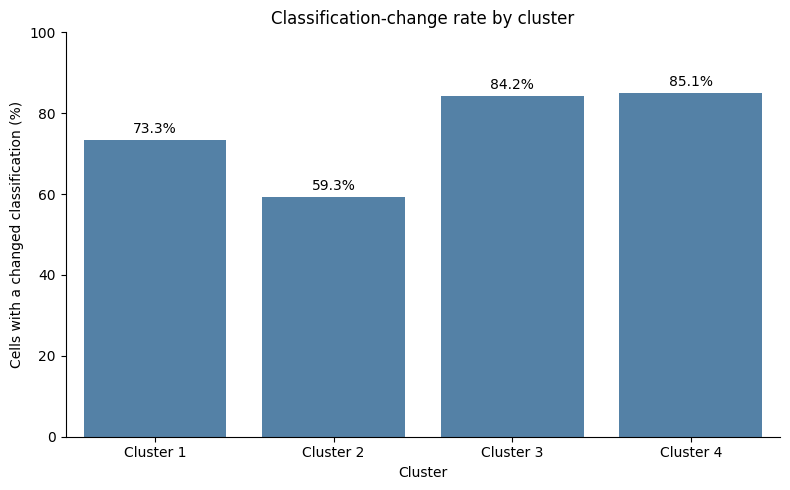

In [30]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=cluster_change_summary,
    x="cluster_label",
    y="change_rate",
    color="steelblue"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

ax.set(
    title="Classification-change rate by cluster",
    xlabel="Cluster",
    ylabel="Cells with a changed classification (%)",
    ylim=(0, 100)
)

sns.despine()
plt.tight_layout()
plt.show()

## 6. Conclusion

K-means clustering identified four geographical and agricultural groups within the selected Lincolnshire area.

The four-cluster solution produced the highest silhouette score of the tested alternatives, at 0.215. This relatively low score indicates that the clusters overlap and should be treated as broad patterns rather than sharply separated groups.

The clusters differed in their location, land-use composition and average classification confidence:

Cluster 1 represented a south-western, mixed-arable area. Cluster 2 was dominated by winter crops and had the highest average classification confidence. Cluster 3 represented a diverse eastern area with relatively low confidence. Cluster 4 represented a mixed north-western area with relatively low confidence. Cluster 2 had the lowest classification-change rate at 59.3%, while Clusters 3 and 4 had the highest rates at 84.2% and 85.1%. This suggests an association between the characteristics of a cluster, classification confidence and year-to-year stability.

The clusters were created using only 2024 information. The 2025 data was used afterwards for interpretation and did not influence the clustering.

These results are exploratory. Observed changes may represent genuine crop rotation, changes in land use or differences in the annual CROME classification process.